# Module 1.7 — 1D Diffusion Equation

**The equation:**
$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

where $\alpha$ is the **diffusivity** — same equation, different physical interpretation depending on context:

| Field | $u$ | $\alpha$ |
|-------|-----|----------|
| Heat conduction | Temperature $T$ | Thermal diffusivity $k/\rho c_p$ |
| Viscous flow | Velocity $u$ | Kinematic viscosity $\nu$ |
| Mass diffusion | Concentration $C$ | Mass diffusivity $D$ |
| Turbulence | TKE $k$ | Effective diffusivity $\nu + \nu_t/\sigma_k$ |

**Why this module is critical before SIMPLE:**
The viscous terms in the Navier-Stokes equations are diffusion terms ($\nu\nabla^2\mathbf{u}$). The stability of the momentum solver depends entirely on choosing the right time-stepping scheme for diffusion. This module explains why.

**Roadmap:**
1. Physical intuition — what diffusion actually does to a field
2. Explicit (FTCS) scheme — simple to code, severely limited
3. The diffusion stability condition — why it is much harsher than CFL
4. Implicit (BTCS) scheme — unconditionally stable, one tridiagonal solve
5. Crank-Nicolson — second-order accurate in time and space
6. Fourier stability analysis — prove stability from first principles
7. Comparison: when to use each scheme

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

## 1. Physical Intuition — Why Diffusion Smooths Everything

### The hot rod analogy

Hold a metal rod with one end in a flame. Heat flows from the hot end toward the cold end — not at a fixed wave speed like advection, but by smoothing out temperature gradients. A spike in temperature spreads outward and flattens. Sharp differences get erased over time.

Mathematically, the second derivative $\partial^2 T/\partial x^2$ tells you the **concavity** of the temperature profile:
- If $T$ is concave up (valley): $T'' > 0$ → temperature increases there
- If $T$ is concave down (peak): $T'' < 0$ → temperature decreases there

In plain English: **peaks get shorter, valleys fill up**. Diffusion is anti-curvature.

### Exact solution by Fourier analysis

The exact solution for a single sine-wave initial condition $u(x,0) = \sin(kx)$ is:

$$u(x,t) = \sin(kx) \cdot e^{-\alpha k^2 t}$$

Two key observations:
1. High wavenumbers ($k$ large) decay **exponentially faster** — fine-scale features vanish quickly
2. The decay rate is $\alpha k^2$ — proportional to the square of the wavenumber

This means: the diffusion equation acts as a **low-pass filter** on the spatial field. Any sharp feature (high $k$) is quickly smoothed out. Over long times, only the lowest-wavenumber components survive.

## 2. Explicit Scheme (FTCS) — Simple but Restricted

### Discretisation

Forward in time, central in space:

$$\frac{u^{n+1}_i - u^n_i}{\Delta t} = \alpha \frac{u^n_{i+1} - 2u^n_i + u^n_{i-1}}{\Delta x^2}$$

Solve for $u^{n+1}_i$:

$$u^{n+1}_i = u^n_i + r(u^n_{i+1} - 2u^n_i + u^n_{i-1})$$

where $r = \alpha\Delta t/\Delta x^2$ is the **diffusion number** (analogous to CFL for advection).

This is a single explicit formula — incredibly simple to code:

```python
u[1:-1] += r * (u[2:] - 2*u[1:-1] + u[:-2])
```

### The stability condition — much harsher than CFL

From von Neumann stability analysis (Section 6 below), the explicit scheme is stable only when:

$$r = \frac{\alpha \Delta t}{\Delta x^2} \leq \frac{1}{2}$$

This means: $\Delta t \leq \frac{\Delta x^2}{2\alpha}$.

**Why this is so restrictive:** the time step scales with $\Delta x^2$, not $\Delta x$. Halving the grid spacing requires **four times** more time steps (compared to twice more for advection). Refining a 2D diffusion grid by 2× requires $2^3 = 8$× more compute; in 3D it is $2^4 = 16$×.

For CFD in viscous flows: near a solid wall, $\Delta x$ can be $10^{-5}$ m. The explicit stability limit gives $\Delta t \sim 10^{-10}$ s — completely infeasible for any flow that takes seconds to develop. This is why all real CFD codes use implicit schemes for diffusion.

## 3. Implicit Scheme (BTCS) — Unconditionally Stable

### Key idea: use the new time level on the right side

Backward in time, central in space:

$$\frac{u^{n+1}_i - u^n_i}{\Delta t} = \alpha \frac{u^{n+1}_{i+1} - 2u^{n+1}_i + u^{n+1}_{i-1}}{\Delta x^2}$$

This can't be solved one cell at a time — all $u^{n+1}$ values are unknown simultaneously. Rearranging:

$$-r\,u^{n+1}_{i-1} + (1+2r)\,u^{n+1}_i - r\,u^{n+1}_{i+1} = u^n_i$$

This is a **tridiagonal linear system** $A\mathbf{u}^{n+1} = \mathbf{u}^n$:

$$\begin{pmatrix} 1+2r & -r & & \\ -r & 1+2r & -r & \\ & \ddots & \ddots & \ddots \\ & & -r & 1+2r \end{pmatrix} \begin{pmatrix} u_1 \\ u_2 \\ \vdots \\ u_{N-1} \end{pmatrix}^{n+1} = \begin{pmatrix} u_1 \\ u_2 \\ \vdots \\ u_{N-1} \end{pmatrix}^n$$

Solve with `scipy.linalg.solve_banded` — $O(N)$ operations per time step.

**Key property: unconditionally stable for all $r$** — you can take arbitrarily large time steps. The solution remains bounded. Large time steps reduce accuracy (first-order in time) but never blow up.

### Crank-Nicolson — the best of both

Average the explicit and implicit right-hand sides:

$$\frac{u^{n+1}_i - u^n_i}{\Delta t} = \frac{\alpha}{2}\left[\frac{u^n_{i+1}-2u^n_i+u^n_{i-1}}{\Delta x^2} + \frac{u^{n+1}_{i+1}-2u^{n+1}_i+u^{n+1}_{i-1}}{\Delta x^2}\right]$$

Result: second-order accurate in both time and space, unconditionally stable. This is the default scheme for the heat equation and for the viscous terms in many N-S solvers.

=== Scheme comparison ===
Explicit FTCS:     dt = 4.0812e-03 s,  nt =    735 steps
Implicit BTCS:     dt = 2.0406e-01 s,  nt =     14 steps  (52× fewer!)
Crank-Nicolson:    dt = 2.0406e-01 s,  nt =     14 steps

L2 errors vs exact:
  Explicit FTCS       : 0.00343
  Implicit BTCS       : 0.01276
  Crank-Nicolson      : 0.02598

CN has the same number of time steps as BTCS but better accuracy
because it is second-order in time (BTCS is first-order).


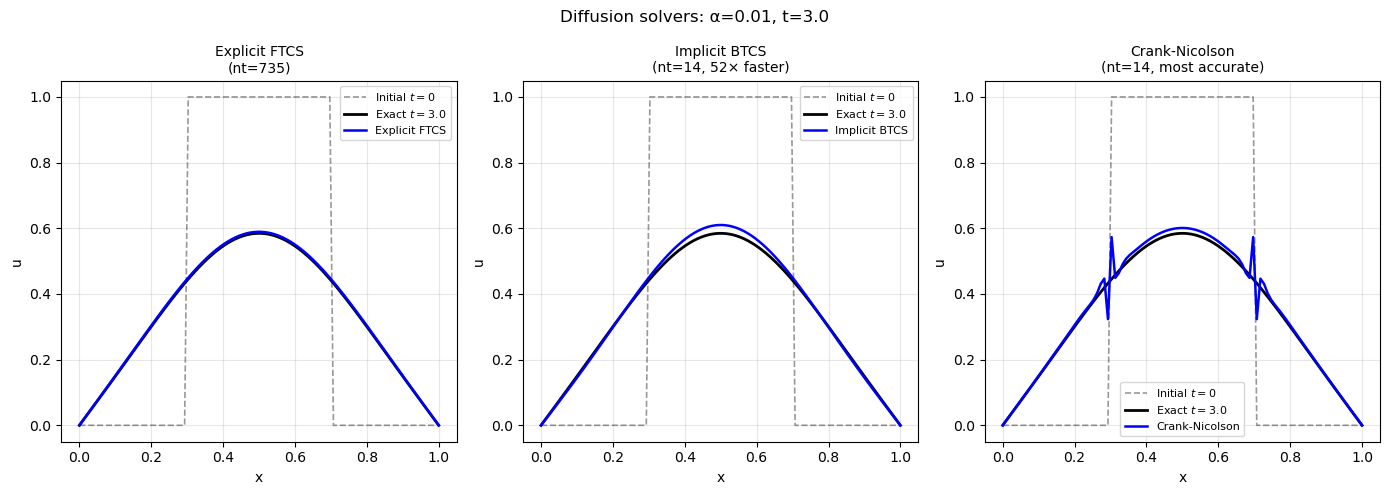

In [2]:
# ── Three diffusion solvers: explicit, implicit (BTCS), Crank-Nicolson ───────

def diffuse_explicit(u0, alpha, dx, dt, nt):
    """FTCS: simple, first-order, requires r <= 0.5."""
    u = u0.copy()
    r = alpha * dt / dx**2
    for _ in range(nt):
        u[1:-1] += r * (u[2:] - 2*u[1:-1] + u[:-2])
        # Dirichlet BCs: u[0]=u[-1]=0 are preserved by not touching boundaries
    return u

def build_tridiagonal(N, r, theta=1.0):
    """
    Build banded matrix for implicit diffusion.
    theta=1.0 → BTCS (fully implicit)
    theta=0.5 → Crank-Nicolson
    Returns ab (banded form for solve_banded), plus RHS multiplier for u^n.
    """
    ab      = np.zeros((3, N-2))       # N-2 interior points
    ab[0, 1:]  = -theta * r             # super-diagonal
    ab[1, :]   = 1 + 2*theta*r         # main diagonal
    ab[2, :-1] = -theta * r             # sub-diagonal
    return ab

def diffuse_implicit(u0, alpha, dx, dt, nt, theta=1.0):
    """
    theta=1.0 → BTCS,  theta=0.5 → Crank-Nicolson.
    Both solve a tridiagonal system each step.
    """
    u  = u0.copy()
    r  = alpha * dt / dx**2
    ab = build_tridiagonal(len(u), r, theta)

    for _ in range(nt):
        # Build RHS: u^n plus explicit part (for CN)
        rhs = u[1:-1].copy()
        if theta < 1.0:   # Crank-Nicolson: add explicit part
            rhs += (1-theta)*r * (u[:-2] - 2*u[1:-1] + u[2:])
        # BCs enter as: first row gets +r*u[0]=0, last row gets +r*u[-1]=0
        u[1:-1] = solve_banded((1, 1), ab, rhs)
    return u

# ── Exact solution (Fourier series) for top-hat IC ───────────────────────────
def exact_diffusion(x, T, alpha, n_terms=40):
    u = np.zeros_like(x)
    for n in range(1, n_terms+1):
        # Fourier coefficients for top-hat on [0.3, 0.7] ⊂ [0,1]
        bn = (2.0 / (n*np.pi)) * (np.cos(n*np.pi*0.3) - np.cos(n*np.pi*0.7))
        u += bn * np.exp(-alpha * (n*np.pi)**2 * T) * np.sin(n*np.pi*x)
    return u

# ── Setup ────────────────────────────────────────────────────────────────────
N     = 100
alpha = 0.01
T_end = 3.0
dx    = 1.0 / (N - 1)
x     = np.linspace(0, 1, N)

u0 = np.zeros(N)
u0[(x > 0.3) & (x < 0.7)] = 1.0
u0[0] = u0[-1] = 0.0

u_exact = exact_diffusion(x, T_end, alpha)

# ── Explicit: must use small dt (r = 0.4 < 0.5) ─────────────────────────────
dt_expl  = 0.4 * dx**2 / alpha   # CFL-like criterion for diffusion
nt_expl  = int(T_end / dt_expl)
u_expl   = diffuse_explicit(u0, alpha, dx, dt_expl, nt_expl)

# ── Implicit: use 50× larger dt ─────────────────────────────────────────────
dt_impl  = 50 * dt_expl
nt_impl  = int(T_end / dt_impl)
u_btcs   = diffuse_implicit(u0, alpha, dx, dt_impl, nt_impl, theta=1.0)
u_cn     = diffuse_implicit(u0, alpha, dx, dt_impl, nt_impl, theta=0.5)

print('=== Scheme comparison ===')
print(f'Explicit FTCS:     dt = {dt_expl:.4e} s,  nt = {nt_expl:6d} steps')
print(f'Implicit BTCS:     dt = {dt_impl:.4e} s,  nt = {nt_impl:6d} steps  ({nt_expl//nt_impl}× fewer!)')
print(f'Crank-Nicolson:    dt = {dt_impl:.4e} s,  nt = {nt_impl:6d} steps')
print()
print('L2 errors vs exact:')
for name, u_num in [('Explicit FTCS', u_expl), ('Implicit BTCS', u_btcs), ('Crank-Nicolson', u_cn)]:
    err = np.sqrt(np.mean((u_num - u_exact)**2))
    print(f'  {name:20s}: {err:.5f}')
print()
print('CN has the same number of time steps as BTCS but better accuracy')
print('because it is second-order in time (BTCS is first-order).')

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, u_num, label in zip(axes,
    [u_expl, u_btcs, u_cn],
    [f'Explicit FTCS\n(nt={nt_expl})',
     f'Implicit BTCS\n(nt={nt_impl}, {nt_expl//nt_impl}× faster)',
     f'Crank-Nicolson\n(nt={nt_impl}, most accurate)']):

    ax.plot(x, u0,      'k--', lw=1.2, alpha=0.4, label='Initial $t=0$')
    ax.plot(x, u_exact, 'k-',  lw=2,              label=f'Exact $t={T_end}$')
    ax.plot(x, u_num,   'b-',  lw=1.8,             label=label.split('\n')[0])
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f'Diffusion solvers: α={alpha}, t={T_end}', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Von Neumann Stability Analysis — Proving $r \leq 1/2$

### The method

Assume the error grows as a Fourier mode: $\epsilon^n_i = G^n e^{ik_m i \Delta x}$ where $G$ is the **amplification factor**. Substitute into the scheme and solve for $G$.

**Stability condition:** $|G| \leq 1$ for all wavenumbers $k_m$.

### For explicit FTCS

Substituting into $u^{n+1}_i = u^n_i + r(u^n_{i+1}-2u^n_i+u^n_{i-1})$:

$$G = 1 + r(e^{ik\Delta x} - 2 + e^{-ik\Delta x}) = 1 + r(2\cos(k\Delta x) - 2) = 1 - 4r\sin^2\!\left(\frac{k\Delta x}{2}\right)$$

For stability: $|G| \leq 1$, i.e. $-1 \leq 1 - 4r\sin^2(\theta) \leq 1$.

The upper bound gives $r \geq 0$ (always true). The lower bound gives:

$$1 - 4r\sin^2(\theta) \geq -1 \implies r \leq \frac{1}{2\sin^2(\theta)} \geq \frac{1}{2}$$

Worst case ($\theta = \pi/2$, the shortest resolved wave): $r \leq 1/2$.

### For implicit BTCS

$$G = \frac{1}{1 + 4r\sin^2(k\Delta x/2)}$$

Since the denominator $\geq 1$ always, $|G| \leq 1$ for all $r$ — **unconditionally stable**.

## Summary

| Scheme | Stability | Order (space×time) | Cost per step | When to use |
|--------|-----------|-------------------|---------------|-------------|
| Explicit FTCS | $r \leq 1/2$ | 2×1 | $O(N)$ (no solve) | Quick tests, coarse grids, pedagogy |
| Implicit BTCS | Unconditional | 2×1 | $O(N)$ (tridiag) | Steady state, coarse time accuracy |
| Crank-Nicolson | Unconditional | 2×2 | $O(N)$ (tridiag) | Time-accurate simulations (preferred) |

**In the Navier-Stokes solver (Module 2):**
Viscous terms are discretised implicitly (BTCS or CN) to avoid the $r \leq 1/2$ constraint — otherwise near-wall cells with tiny $\Delta y$ would force microsecond time steps on a flow that takes seconds to develop.

---
**Next:** Module 1.8 — 1D Burgers' Equation: combining advection and diffusion, introducing nonlinearity, and witnessing shock formation.

## 7. Effect of Diffusion Coefficient $\alpha$

Higher $\alpha$ = faster spreading. Lower $\alpha$ = slower, sharper features preserved longer.

Notice we must keep $r = \alpha \Delta t / \Delta x^2 \leq 0.5$, so when $\alpha$ increases we must shrink $\Delta t$.

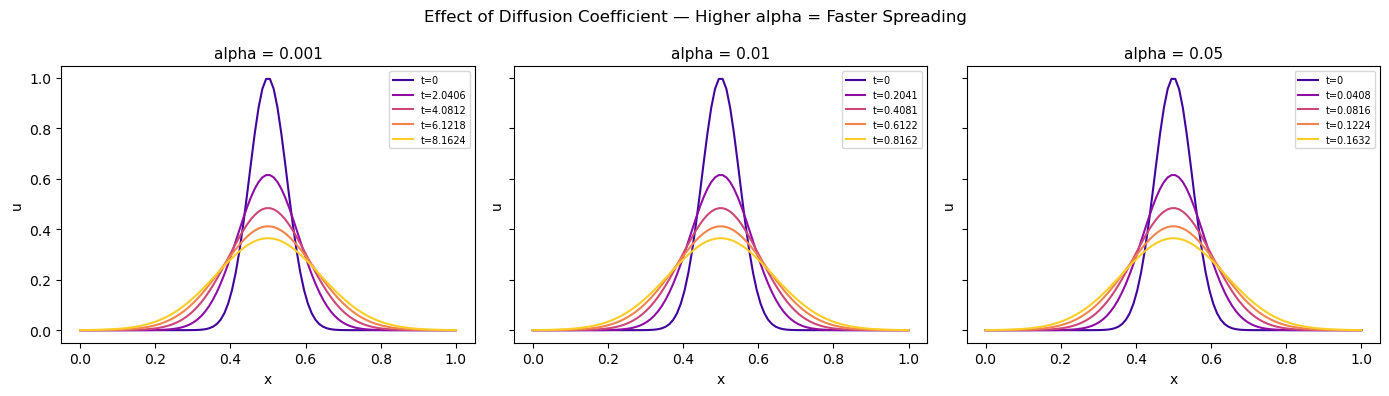

In [6]:
alphas = [0.001, 0.01, 0.05]   # slow → fast diffusion
r_fixed = 0.4                  # keep r constant (stable)
nt_fixed = 200

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, a in zip(axes, alphas):
    dt_a = r_fixed * dx**2 / a
    snaps, _ = solve_explicit(u0, a, dx, dt_a, nt_fixed, save_every=50)
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(snaps)))
    for (step, u_snap), color in zip(snaps, colors):
        label = f"t={step*dt_a:.4f}" if step > 0 else "t=0"
        ax.plot(x, u_snap, color=color, lw=1.5, label=label)
    ax.set_title(f"alpha = {a}", fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("u")
    ax.legend(fontsize=7)

plt.suptitle("Effect of Diffusion Coefficient — Higher alpha = Faster Spreading", fontsize=12)
plt.tight_layout(); plt.show()

---
## Bonus: Curvature Intuition — Why Peaks Decay and Valleys Fill Up

The diffusion equation is driven by curvature:

$$\frac{\partial u}{\partial t} = \alpha \underbrace{\frac{\partial^2 u}{\partial x^2}}_{\text{curvature}}$$

| Shape at a point | $\partial^2 u/\partial x^2$ | $\partial u/\partial t$ | What happens |
|---|---|---|---|
| Peak (convex) | $< 0$ | $< 0$ | $u$ **decreases** — peak shrinks |
| Valley (concave) | $> 0$ | $> 0$ | $u$ **increases** — valley fills up |
| Flat | $= 0$ | $= 0$ | $u$ unchanged |

We'll construct a profile with both a **peak** and a **valley** and watch each one respond differently — yet governed by the same equation.

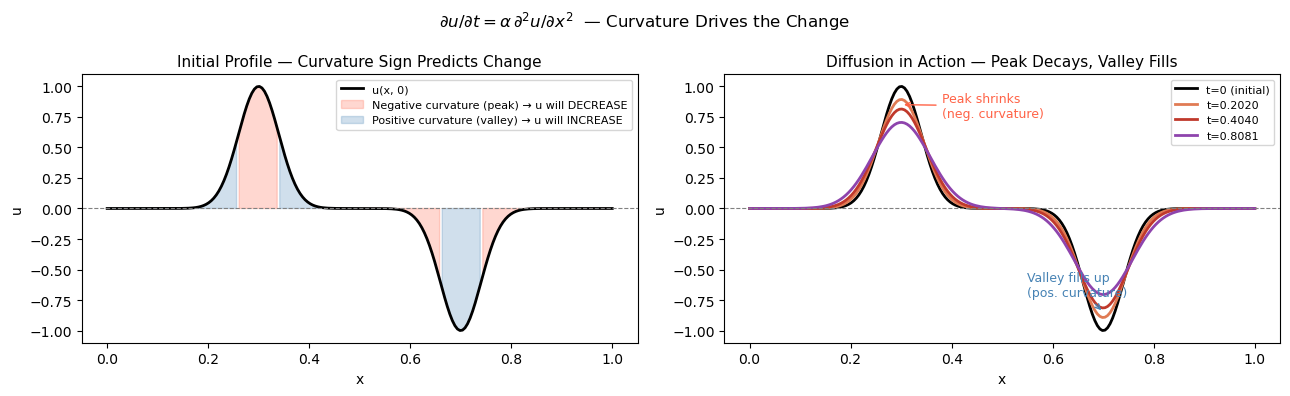

PEAK  at x=0.3: curvature < 0 → du/dt < 0 → amplitude DECREASES over time
VALLEY at x=0.7: curvature > 0 → du/dt > 0 → amplitude INCREASES (fills up)

Both are driven by the SAME diffusion equation — only the sign of curvature differs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Grid ───────────────────────────────────────────────────────────────────────
L  = 1.0; N = 200; dx = L / (N - 1)
x  = np.linspace(0, L, N)

# ── Initial condition: one PEAK + one VALLEY ───────────────────────────────────
# Peak at x=0.3  (Gaussian bump above zero)
# Valley at x=0.7 (inverted Gaussian, dips below zero)
peak   =  np.exp(-((x - 0.3)**2) / (2 * 0.04**2))
valley = -np.exp(-((x - 0.7)**2) / (2 * 0.04**2))
u0_cv  = peak + valley

# ── Compute curvature of initial profile (2nd derivative via FD) ───────────────
curv = np.zeros(N)
curv[1:-1] = (u0_cv[2:] - 2*u0_cv[1:-1] + u0_cv[:-2]) / dx**2
# curv is d²u/dx² — positive = valley, negative = peak

# ── Run explicit FTCS for a few steps ─────────────────────────────────────────
alpha = 0.001           # small alpha → slow diffusion, easy to see the effect
r     = 0.4
dt    = r * dx**2 / alpha
nt_short = 80           # just enough to see the initial response

u = u0_cv.copy()
snapshots = [u0_cv.copy()]
save_at   = [20, 40, 80]

for step in range(1, nt_short + 1):
    u_new = u.copy()
    u_new[1:-1] = u[1:-1] + r * (u[2:] - 2*u[1:-1] + u[:-2])
    u_new[0] = u_new[-1] = 0.0
    u = u_new
    if step in save_at:
        snapshots.append(u.copy())

# ── Figure 1: curvature map + initial profile ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(x, u0_cv, "k-", lw=2, label="u(x, 0)")
ax.axhline(0, color="gray", lw=0.8, ls="--")

# shade regions by curvature sign
ax.fill_between(x, u0_cv, where=(curv < 0), alpha=0.25, color="tomato",
                label="Negative curvature (peak) → u will DECREASE")
ax.fill_between(x, u0_cv, where=(curv > 0), alpha=0.25, color="steelblue",
                label="Positive curvature (valley) → u will INCREASE")

ax.set_title("Initial Profile — Curvature Sign Predicts Change", fontsize=11)
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.legend(fontsize=8)

# ── Figure 2: time evolution showing peaks decay and valleys fill ──────────────
ax2 = axes[1]
colors = ["black", "#e07b54", "#c0392b", "#8e44ad"]
labels = ["t=0 (initial)", f"t={20*dt:.4f}", f"t={40*dt:.4f}", f"t={80*dt:.4f}"]

for snap, color, label in zip(snapshots, colors, labels):
    ax2.plot(x, snap, color=color, lw=2, label=label)

ax2.axhline(0, color="gray", lw=0.8, ls="--")
ax2.annotate("Peak shrinks\n(neg. curvature)", xy=(0.3, 0.85), xytext=(0.38, 0.75),
             arrowprops=dict(arrowstyle="->", color="tomato"), fontsize=9, color="tomato")
ax2.annotate("Valley fills up\n(pos. curvature)", xy=(0.7, -0.85), xytext=(0.55, -0.72),
             arrowprops=dict(arrowstyle="->", color="steelblue"), fontsize=9, color="steelblue")

ax2.set_title("Diffusion in Action — Peak Decays, Valley Fills", fontsize=11)
ax2.set_xlabel("x"); ax2.set_ylabel("u")
ax2.legend(fontsize=8)

plt.suptitle(r"$\partial u/\partial t = \alpha\,\partial^2 u/\partial x^2$  — Curvature Drives the Change",
             fontsize=12)
plt.tight_layout()
plt.show()

print("PEAK  at x=0.3: curvature < 0 → du/dt < 0 → amplitude DECREASES over time")
print("VALLEY at x=0.7: curvature > 0 → du/dt > 0 → amplitude INCREASES (fills up)")
print()
print("Both are driven by the SAME diffusion equation — only the sign of curvature differs.")